In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline 
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
df = pd.read_csv('lung_cancer_data.csv')

In [3]:
df.head()

,Patient_ID,Age,Gender,Smoking_History,Tumor_Size_mm,Tumor_Location,Stage,Treatment,Survival_Months,Ethnicity,...,Alanine_Aminotransferase_Level,Aspartate_Aminotransferase_Level,Creatinine_Level,LDH_Level,Calcium_Level,Phosphorus_Level,Glucose_Level,Potassium_Level,Sodium_Level,Smoking_Pack_Years
0,Patient0000,68,Male,Current Smoker,81.678677,Lower Lobe,Stage III,Surgery,44,Hispanic,...,27.985571,46.801214,1.245849,239.240255,10.366307,3.547734,113.919243,4.968163,139.822861,17.006956
1,Patient0001,58,Male,Never Smoked,78.448272,Lower Lobe,Stage I,Radiation Therapy,101,Caucasian,...,30.120956,39.711531,1.463231,233.515237,10.081731,2.945020,101.321578,3.896795,135.449361,93.270893
2,Patient0002,44,Male,Former Smoker,67.714305,Lower Lobe,Stage I,Chemotherapy,69,African American,...,5.882418,32.640602,0.630109,169.037460,8.660892,4.637399,78.214177,4.369050,143.377155,70.348376
3,Patient0003,72,Male,Current Smoker,70.806008,Lower Lobe,Stage III,Chemotherapy,95,African American,...,38.908154,44.319393,0.594342,213.967590,8.832669,3.617098,127.895361,4.348474,138.586005,19.828128
4,Patient0004,37,Female,Never Smoked,87.272433,Lower Lobe,Stage IV,Radiation Therapy,105,Asian,...,26.344877,15.746906,1.478239,118.187543,9.247609,4.773255,148.801185,3.671976,141.230724,81.047456


In [4]:
df.isnull().sum()

Patient_ID                          0
Age                                 0
Gender                              0
Smoking_History                     0
Tumor_Size_mm                       0
Tumor_Location                      0
Stage                               0
Treatment                           0
Survival_Months                     0
Ethnicity                           0
Insurance_Type                      0
Family_History                      0
Comorbidity_Diabetes                0
Comorbidity_Hypertension            0
Comorbidity_Heart_Disease           0
Comorbidity_Chronic_Lung_Disease    0
Comorbidity_Kidney_Disease          0
Comorbidity_Autoimmune_Disease      0
Comorbidity_Other                   0
Performance_Status                  0
Blood_Pressure_Systolic             0
Blood_Pressure_Diastolic            0
Blood_Pressure_Pulse                0
Hemoglobin_Level                    0
White_Blood_Cell_Count              0
Platelet_Count                      0
Albumin_Leve

In [5]:
df.drop(['Ethnicity'], axis=1, inplace=True)
df.drop(['Insurance_Type'], axis=1, inplace=True)
df.drop(['Gender'], axis=1, inplace=True)
df.drop(['Patient_ID'], axis=1, inplace=True)

In [6]:
Categorical = ['Smoking_History','Tumor_Location','Stage','Treatment', 'Family_History','Comorbidity_Diabetes','Comorbidity_Hypertension','Comorbidity_Heart_Disease','Comorbidity_Chronic_Lung_Disease','Comorbidity_Kidney_Disease','Comorbidity_Autoimmune_Disease','Comorbidity_Other']
# #Initialize OneHotEncoder
# encoder = OneHotEncoder(sparse_output=False)
# # Apply one-hot encoding to the categorical columns
# one_hot_encoded = encoder.fit_transform(df[Categorical])
# #We use get_feature_names_out() to get the column names for the encoded data
# one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(Categorical))
# # Concatenate the one-hot encoded dataframe with the original dataframe
# df_encoded = pd.concat([df, one_hot_df], axis=1)

# # Drop the original categorical columns
# df_encoded = df_encoded.drop(Categorical, axis=1)
label_encoders = {}

for column in Categorical:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

In [7]:
df.head()

,Age,Smoking_History,Tumor_Size_mm,Tumor_Location,Stage,Treatment,Survival_Months,Family_History,Comorbidity_Diabetes,Comorbidity_Hypertension,...,Alanine_Aminotransferase_Level,Aspartate_Aminotransferase_Level,Creatinine_Level,LDH_Level,Calcium_Level,Phosphorus_Level,Glucose_Level,Potassium_Level,Sodium_Level,Smoking_Pack_Years
0,68,0,81.678677,0,2,2,44,0,1,1,...,27.985571,46.801214,1.245849,239.240255,10.366307,3.547734,113.919243,4.968163,139.822861,17.006956
1,58,2,78.448272,0,0,1,101,1,1,1,...,30.120956,39.711531,1.463231,233.515237,10.081731,2.945020,101.321578,3.896795,135.449361,93.270893
2,44,1,67.714305,0,0,0,69,1,0,0,...,5.882418,32.640602,0.630109,169.037460,8.660892,4.637399,78.214177,4.369050,143.377155,70.348376
3,72,0,70.806008,0,2,0,95,1,1,0,...,38.908154,44.319393,0.594342,213.967590,8.832669,3.617098,127.895361,4.348474,138.586005,19.828128
4,37,2,87.272433,0,3,1,105,0,1,1,...,26.344877,15.746906,1.478239,118.187543,9.247609,4.773255,148.801185,3.671976,141.230724,81.047456


In [8]:
corr_matrix = df.corr()
corr_matrix['Stage'].sort_values(ascending=False)

Stage                               1.000000
Tumor_Location                      0.013032
Sodium_Level                        0.009387
Comorbidity_Heart_Disease           0.007746
Age                                 0.006894
Albumin_Level                       0.006026
Survival_Months                     0.005474
Family_History                      0.004662
Phosphorus_Level                    0.003144
Performance_Status                  0.002454
Smoking_Pack_Years                  0.002081
LDH_Level                           0.001566
Treatment                           0.001412
Alanine_Aminotransferase_Level      0.000893
Smoking_History                     0.000707
White_Blood_Cell_Count              0.000348
Alkaline_Phosphatase_Level         -0.000143
Aspartate_Aminotransferase_Level   -0.000644
Hemoglobin_Level                   -0.000806
Platelet_Count                     -0.000994
Comorbidity_Chronic_Lung_Disease   -0.001626
Tumor_Size_mm                      -0.001959
Blood_Pres

In [9]:
df.shape

(23658, 34)

In [10]:
# Feature columns (excluding Patient_ID and Stage)
X = df.drop(['Stage'], axis=1)

In [11]:
# Target column
y = df['Stage']

In [12]:

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [14]:
scaler = StandardScaler()

# Scale X (features)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)





Stage
3    0.254079
2    0.250317
0    0.249598
1    0.246006
Name: proportion, dtype: float64


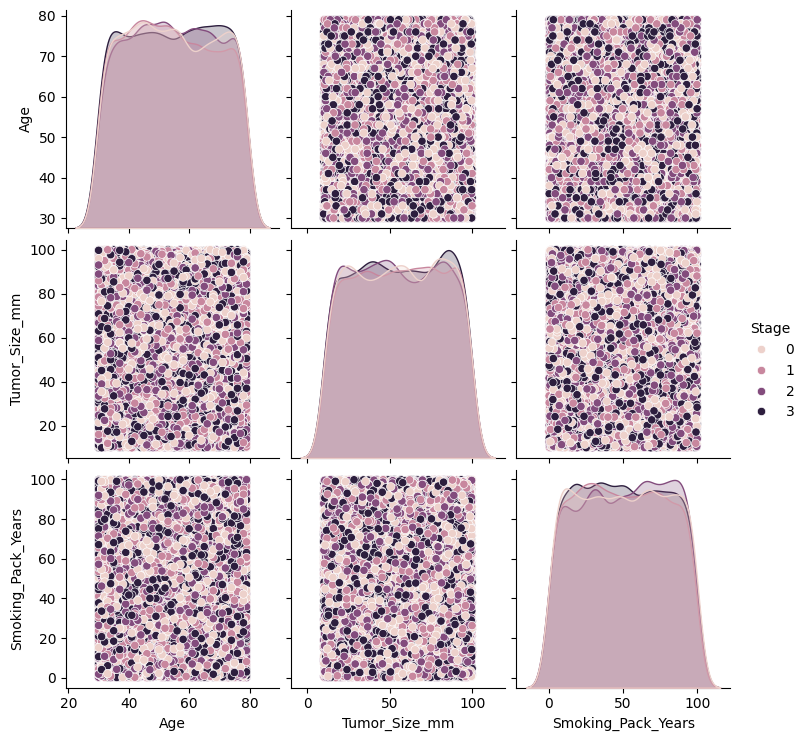

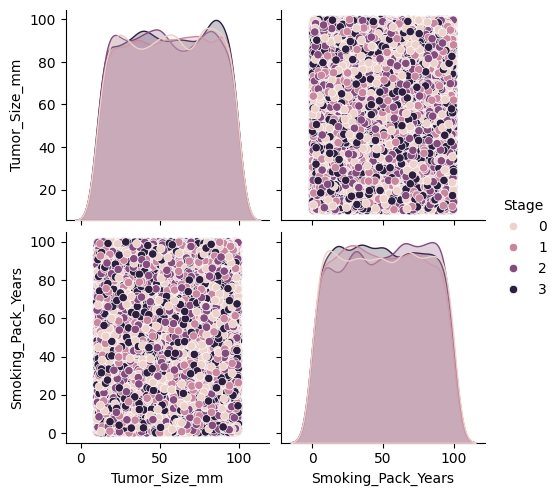

In [16]:
print(df['Stage'].value_counts(normalize=True))
sns.pairplot(df[['Age', 'Tumor_Size_mm', 'Smoking_Pack_Years', 'Stage']], hue='Stage')
# Create age buckets
df['Age_Bucket'] = pd.cut(df['Age'], bins=[0, 50, 65, np.inf], labels=['<50', '50-65', '>65'])

# Plot the pairplot again with the new feature
sns.pairplot(df[['Age_Bucket', 'Tumor_Size_mm', 'Smoking_Pack_Years', 'Stage']], hue='Stage')

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU

# Build the model with additional layers
model = Sequential()

# First hidden layer
model.add(Dense(128, input_shape=(X_train.shape[1],)))
model.add(LeakyReLU(alpha=0.1))  # Adding LeakyReLU activation
model.add(Dropout(0.5))

# Second hidden layer
model.add(Dense(256))
model.add(LeakyReLU(alpha=0.1))  # Adding LeakyReLU activation
model.add(Dropout(0.5))

# Third hidden layer
model.add(Dense(512))
model.add(LeakyReLU(alpha=0.1))  # Adding LeakyReLU activation
model.add(Dropout(0.5))

# Fourth hidden layer (additional layer)
model.add(Dense(512))
model.add(LeakyReLU(alpha=0.1))  # Adding LeakyReLU activation
model.add(Dropout(0.5))

# Output layer
model.add(Dense(len(y.unique()), activation='softmax'))  # Using softmax for multi-class classification



optimizer = Adam(learning_rate=0.001)  # Lower learning rate
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])


# Print model summary
model.summary()


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_51 (Dense)                │ (None, 128)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_20 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_21 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_22 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_23 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 433,668 (1.65 MB)

 Trainable params: 433,668 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils import class_weight

# early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/100
592/592 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2458 - loss: 1.4460 - val_accuracy: 0.2350 - val_loss: 1.3880
Epoch 2/100
592/592 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2569 - loss: 1.3931 - val_accuracy: 0.2485 - val_loss: 1.3868
Epoch 3/100
592/592 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2565 - loss: 1.3915 - val_accuracy: 0.2447 - val_loss: 1.3876
Epoch 4/100
592/592 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2595 - loss: 1.3887 - val_accuracy: 0.2460 - val_loss: 1.3891
Epoch 5/100
592/592 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2601 - loss: 1.3897 - val_accuracy: 0.2384 - val_loss: 1.3885
Epoch 6/100
592/592 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2620 - loss: 1.3885 - val_accuracy: 0.2424 - val_loss: 1.3874
Epoch 7/100
592/592 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2488 - loss: 1.3899 - val_accuracy: 0.2348 - val_loss: 1.3880
Epoch 8/100
592/592 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2665 - loss: 1.3871 - val_accu

KeyboardInterrupt: 

In [ ]:
# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(X_test, y_test)

# Make predictions
y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=1)  # Get the class with the highest probability

# Print the classification report
print(f"Test accuracy: {test_acc}")
print(classification_report(y_test, y_pred, target_names=label_encoders['Stage'].classes_))


148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2534 - loss: 1.3866
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test accuracy: 0.2552831768989563
              precision    recall  f1-score   support

     Stage I       0.24      0.09      0.13      1145
    Stage II       0.24      0.04      0.07      1153
   Stage III       0.27      0.30      0.28      1230
    Stage IV       0.25      0.57      0.35      1204

    accuracy                           0.26      4732
   macro avg       0.25      0.25      0.21      4732
weighted avg       0.25      0.26      0.21      4732

